In [ ]:
# ============================================================
#           IPL DATA ANALYSIS PROJECT
# ============================================================
#
# Author   : Your Name
# Tools    : Python, Pandas, NumPy, Matplotlib
# Dataset  : IPL Matches 2008 - 2022 (950 matches)
# Purpose  : Analysing IPL match data to find key insights
#
# Questions Answered:
# 1. Which team won the most matches?
# 2. Which city hosted the most IPL matches?
# 3. How many matches were played per season?
# 4. Who won the most Player of the Match awards?
# 5. Which team won the most tosses?
#
# Key Findings:
# - Mumbai Indians are the most successful IPL team
# - Mumbai city hosted the most matches
# - AB de Villiers won the most Player of the Match awards
# - 2013 had the highest number of matches in IPL history
#
# ============================================================

# 🏏 IPL Data Analysis Project

Analysing IPL match data from 2008 to 2022 using Python, Pandas and Matplotlib.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib

## Dataset
- 950 IPL matches
- 20 columns including teams, cities, winners, players

## Key Insights
- Mumbai Indians won the most matches (129 wins)
- Mumbai city hosted the most matches (160+)
- AB de Villiers won most Player of the Match awards (25)
- 2013 season had the highest number of matches

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("import successfull")

import successfull


In [27]:
ipl = pd.read_csv('ipl-matches.csv')
ipl.shape
ipl.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [5]:
ipl.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [14]:
ipl.isnull().sum()

,0
ID,0
City,51
Date,0
Season,0
MatchNumber,0
Team1,0
Team2,0
Venue,0
TossWinner,0
TossDecision,0


In [7]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [5]:
print("Before cleaning: " ,ipl.shape)
ipl=ipl.dropna(subset=['WinningTeam'])
ipl['City'] = ipl['City'].fillna('Unknown')
ipl['Player_of_Match'] = ipl['Player_of_Match'].fillna('Unknown')
print("After cleaning:", ipl.shape)


Before cleaning:  (950, 20)
After cleaning: (946, 20)


In [25]:
print("Team Which Won the most matches: ")
names=ipl['WinningTeam'].value_counts()
print(names.head(1))



Team Which Won the most matches: 
WinningTeam
Mumbai Indians    131
Name: count, dtype: int64


In [26]:
print("====== Top 5 Teams =======")
print()
print(names.head())

====== Top 5 Teams =======

WinningTeam
Mumbai Indians                 131
Chennai Super Kings            121
Kolkata Knight Riders          114
Royal Challengers Bangalore    109
Rajasthan Royals                96
Name: count, dtype: int64


In [30]:
print("===== Most Matches By Cities =====")
print()
cities = ipl['City'].value_counts()
print(cities.head())

===== Most Matches By Cities =====

City
Mumbai       159
Kolkata       79
Delhi         78
Chennai       67
Bangalore     65
Name: count, dtype: int64


In [33]:
player = ipl['Player_of_Match'].value_counts()
print("==== Who won most Player of the Match awards? ====")
print()
print(player.head(1))
print()

print("==== Which team wins toss the most? ====")
team = ipl['TossWinner'].value_counts()
print()
print(team.head(1))

print()
print("==== How many matches per season? ====")
season = ipl['Season'].value_counts()
print()
print(season)



==== Who won most Player of the Match awards? ====

Player_of_Match
AB de Villiers    25
Name: count, dtype: int64

==== Which team wins toss the most? ====

TossWinner
Mumbai Indians    123
Name: count, dtype: int64

==== How many matches per season? ====

Season
2013       76
2012       74
2022       74
2011       73
2019       60
2021       60
2020/21    60
2009/10    60
2016       60
2018       60
2014       60
2017       59
2015       59
2007/08    58
2009       57
Name: count, dtype: int64


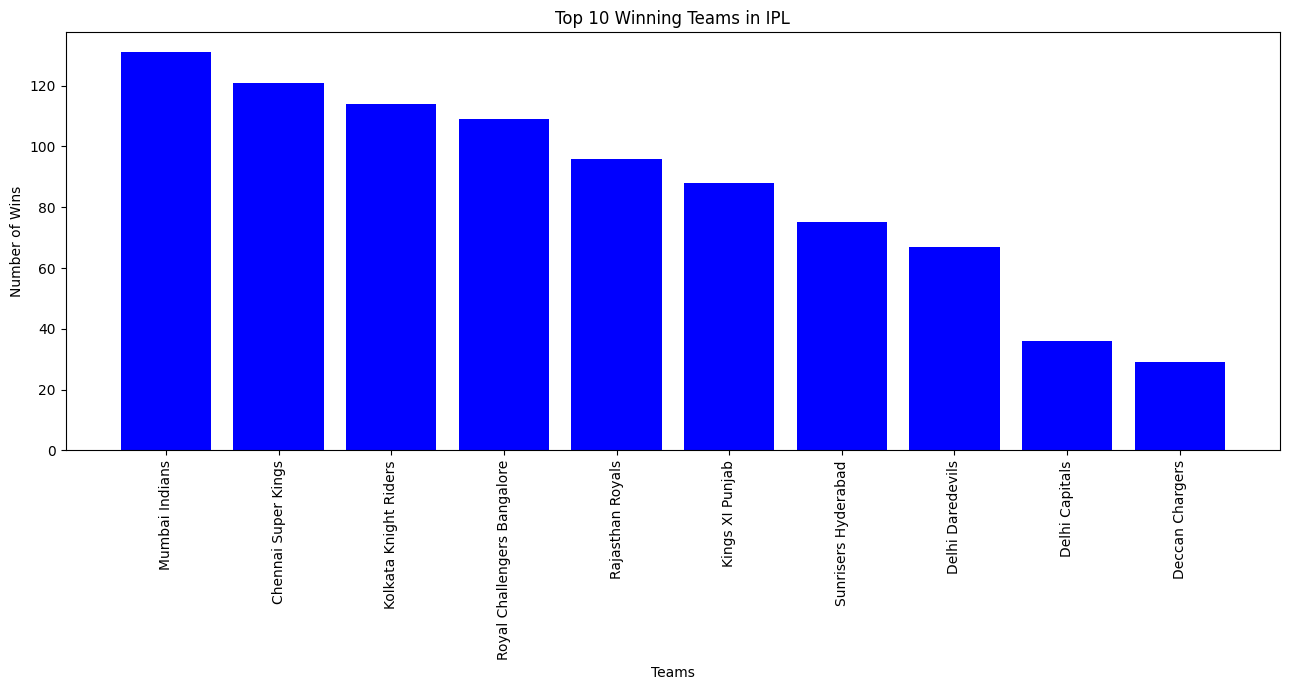

In [44]:
top_teams = ipl['WinningTeam'].value_counts().head(10)

plt.figure(figsize=(13,7))
plt.bar(top_teams.index, top_teams.values, color='blue')
plt.title('Top 10 Winning Teams in IPL')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


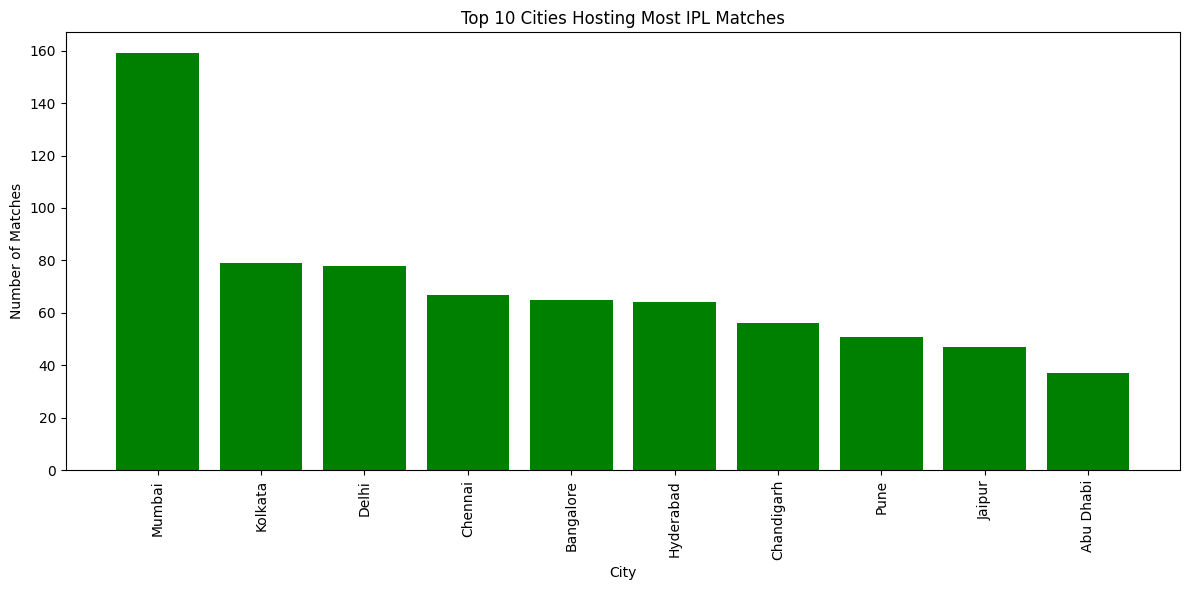

In [47]:
top_cities = ipl['City'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(top_cities.index, top_cities.values, color='green')
plt.title('Top 10 Cities Hosting Most IPL Matches')
plt.xlabel('City')
plt.ylabel('Number of Matches')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

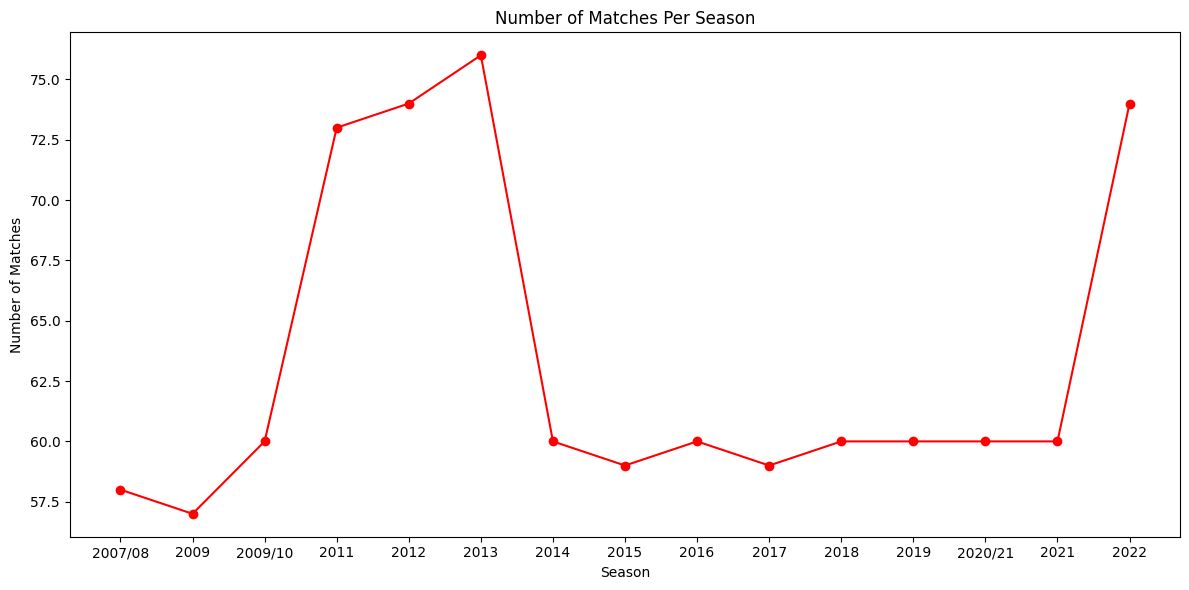

In [46]:
season_matches = ipl['Season'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(season_matches.index, season_matches.values, color='red', marker='o')
plt.title('Number of Matches Per Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

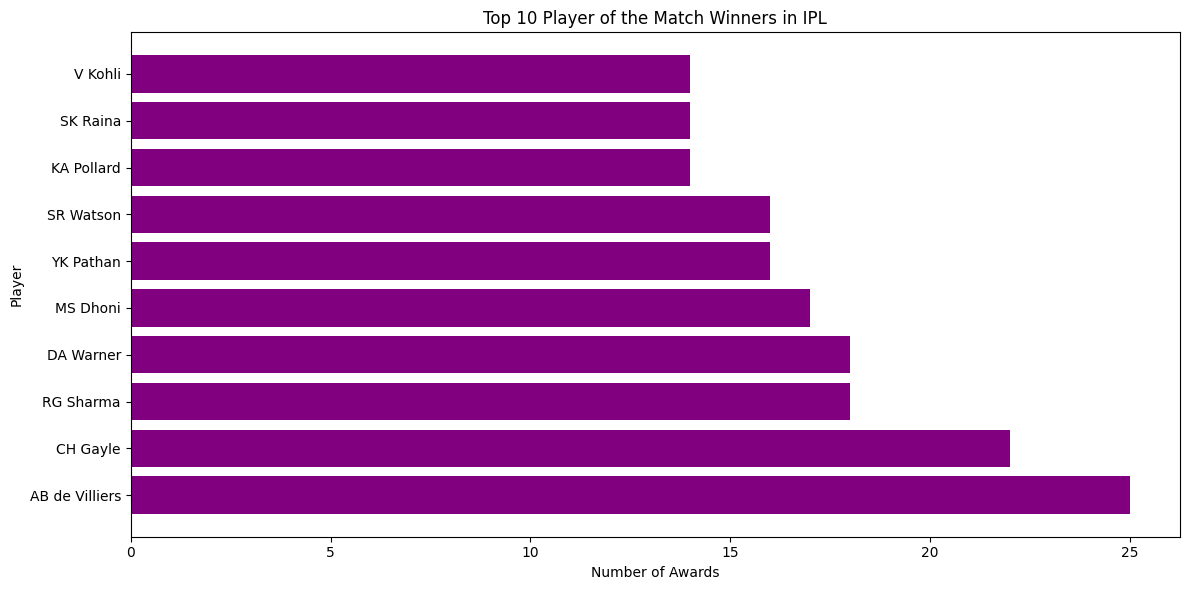

In [48]:
# Top 10 Player of the Match winners
top_players = ipl['Player_of_Match'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.barh(top_players.index, top_players.values, color='purple')
plt.title('Top 10 Player of the Match Winners in IPL')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()